In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

In [2]:
df=pd.DataFrame()

In [3]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [4]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


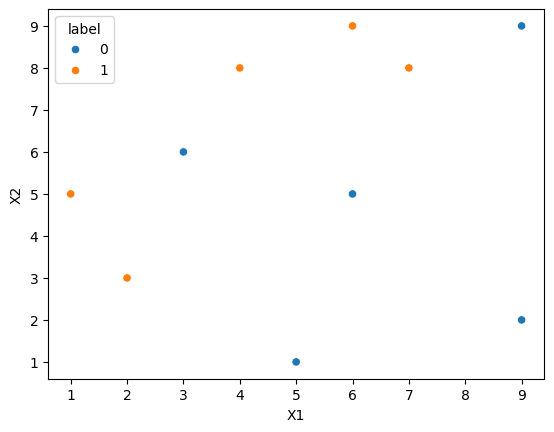

In [5]:
sns.scatterplot(x=df["X1"],y=df["X2"],hue=df["label"])
plt.show()

In [6]:
df["weights"]=1/df.shape[0]

In [7]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
x=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [10]:
dt1=DecisionTreeClassifier(max_depth=1)
dt1.fit(x,y)

DecisionTreeClassifier(max_depth=1)

In [11]:
from sklearn.tree import plot_tree

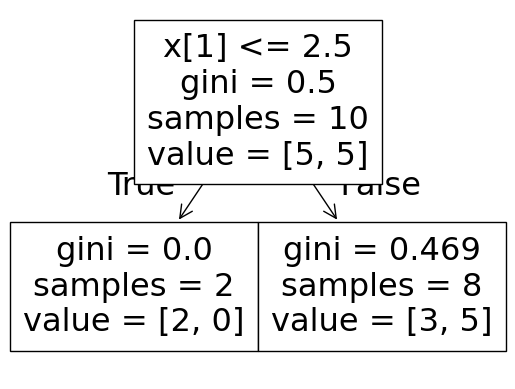

In [12]:
plot_tree(dt1)
plt.show()

In [13]:
from mlxtend.plotting import plot_decision_regions

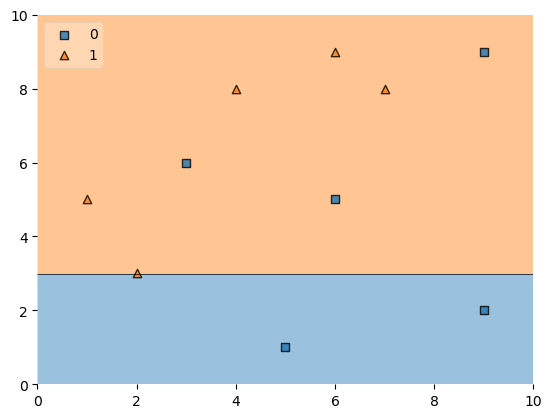

In [14]:
plot_decision_regions(x,y,clf=dt1, legend=2)
plt.show()

In [15]:
df["y_pred"]=dt1.predict(x)

In [16]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [17]:
def calculate_error(row):
    error=0
    if row["label"]!=row["y_pred"]:
        error +=row["weights"]
    else:
        pass
    return error

In [18]:
error=df.apply(calculate_error,axis=1)

In [19]:
error.sum()

np.float64(0.30000000000000004)

In [20]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error))

In [21]:
alpha1=calculate_model_weight(error.sum())

In [22]:
alpha1

np.float64(0.4236489301936017)

In [23]:
def update_row_weights(row,alpha=0.4236489301936017):
    if row["label"]==row["y_pred"]:
        return row["weights"]*np.exp(-alpha)
    else:
        return row["weights"]*np.exp(alpha)

In [24]:
df["new_weights"]=df.apply(update_row_weights,axis=1)

In [25]:
df1=df[["X1","X2","label","new_weights"]]

In [26]:
df1["normalized_weights"]=df["new_weights"]/df["new_weights"].sum()

C:\Users\heman\AppData\Local\Temp\ipykernel_12152\2413206991.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["normalized_weights"]=df["new_weights"]/df["new_weights"].sum()


In [27]:
df1['cumsum_upper']=np.cumsum(df1["normalized_weights"])

In [28]:
df1["cumsum_lower"]=df1['cumsum_upper']-df1["normalized_weights"]

In [29]:
df1.drop(columns=["new_weights"],axis=1,inplace=True)

In [30]:
df1

,X1,X2,label,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.071429,0.071429,0.000000
1,2,3,1,0.071429,0.142857,0.071429
2,3,6,0,0.166667,0.309524,0.142857
3,4,8,1,0.071429,0.380952,0.309524
4,5,1,0,0.071429,0.452381,0.380952
5,6,9,1,0.071429,0.523810,0.452381
6,6,5,0,0.166667,0.690476,0.523810
7,7,8,1,0.071429,0.761905,0.690476
8,9,9,0,0.166667,0.928571,0.761905
9,9,2,0,0.071429,1.000000,0.928571


In [31]:
def create_new_dataset(df):
    indices=[]
    for i in range(df.shape[0]):
        a=np.random.random()
        for index, row in df.iterrows():
            if row["cumsum_upper"] > a and a >row["cumsum_lower"]:
                indices.append(index)
    return indices

In [32]:
indexes=create_new_dataset(df1)

In [33]:
indexes

[4, 6, 2, 4, 6, 8, 8, 8, 2, 2]

In [34]:
df2=df1.iloc[indexes,[0,1,2,3]]

In [35]:
df2

,X1,X2,label,normalized_weights
4,5,1,0,0.071429
6,6,5,0,0.166667
2,3,6,0,0.166667
4,5,1,0,0.071429
6,6,5,0,0.166667
8,9,9,0,0.166667
8,9,9,0,0.166667
8,9,9,0,0.166667
2,3,6,0,0.166667
2,3,6,0,0.166667


In [36]:
dt2=DecisionTreeClassifier(max_depth=1)
dt2.fit(df2.iloc[:,0:2].values,df2["label"].values)

DecisionTreeClassifier(max_depth=1)

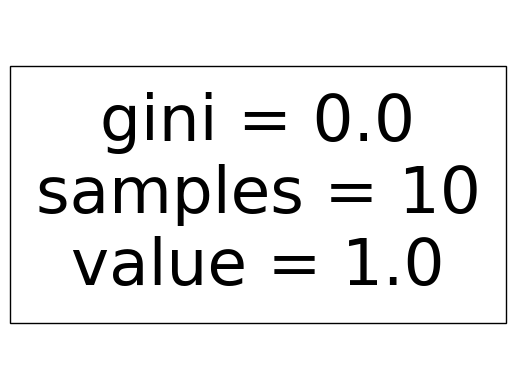

In [37]:
plot_tree(dt2)
plt.show()

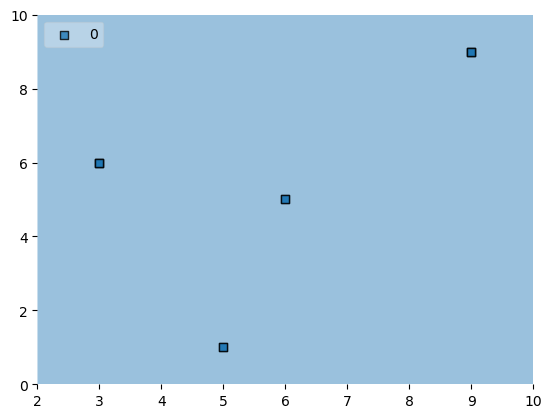

In [38]:
plot_decision_regions(df2.iloc[:,0:2].values,df2["label"].values, clf=dt2, legend=2)
plt.show()

In [39]:
df2["y_pred2"]=dt2.predict(df2.iloc[:,0:2].values)

In [40]:
df2.rename(columns={"y_pred2": "y_pred"}, inplace=True)

In [41]:
df2.rename(columns={"normalized_weights": "weights"}, inplace=True)

In [42]:
df2

,X1,X2,label,weights,y_pred
4,5,1,0,0.071429,0
6,6,5,0,0.166667,0
2,3,6,0,0.166667,0
4,5,1,0,0.071429,0
6,6,5,0,0.166667,0
8,9,9,0,0.166667,0
8,9,9,0,0.166667,0
8,9,9,0,0.166667,0
2,3,6,0,0.166667,0
2,3,6,0,0.166667,0


In [43]:
error2=df2.apply(calculate_error,axis=1).sum()

In [46]:
error2

np.int64(0)

In [44]:
alpha2=calculate_model_weight(error2.sum())

C:\Users\heman\AppData\Local\Temp\ipykernel_12152\3825099260.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return 0.5*np.log((1-error)/(error))


In [45]:
alpha2

np.float64(inf)